In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, compatible_TimeSeries_check, print_wise, get_lagplot
# from useful_stuff.general_utils.RSA import  dRSA
# from useful_stuff.general_utils.II import  dRSA, dynInformationImbalance
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.dataloader import load_concat_regressout_meg
from project_specific_utils.subsampling_lagged_comparisons import multivariate_lagged_comparisons
# from image_processing.gaze_dep_models import save_ANN_features


In [47]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    neu_fs = 100
    gaze_fs = 50
    sq_side = 384
    sensors_group = 'occ'
    model_name = "dino_v3_l"
    pkg = "timm"
    len_or_lag = 600
    pseudotrials_n = 100
    n_model_components = 1000
    pooling = "all"
    PCs_to_regress_out = 50
    iterations_n = 1000
    repetition = 1
    signal_metric = "correlation"
    model_metric = "correlation"
    regress_out_gaze = 'PCR' # or None or pointwise
    PCs_to_regress_out = 50
    analysis_type = "II"
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg)
mod_fs = config["movie_fs"]
model_len = [round(i*cfg.neu_fs/config["movie_fs"]) for i in config["model_len"]]

# A2B

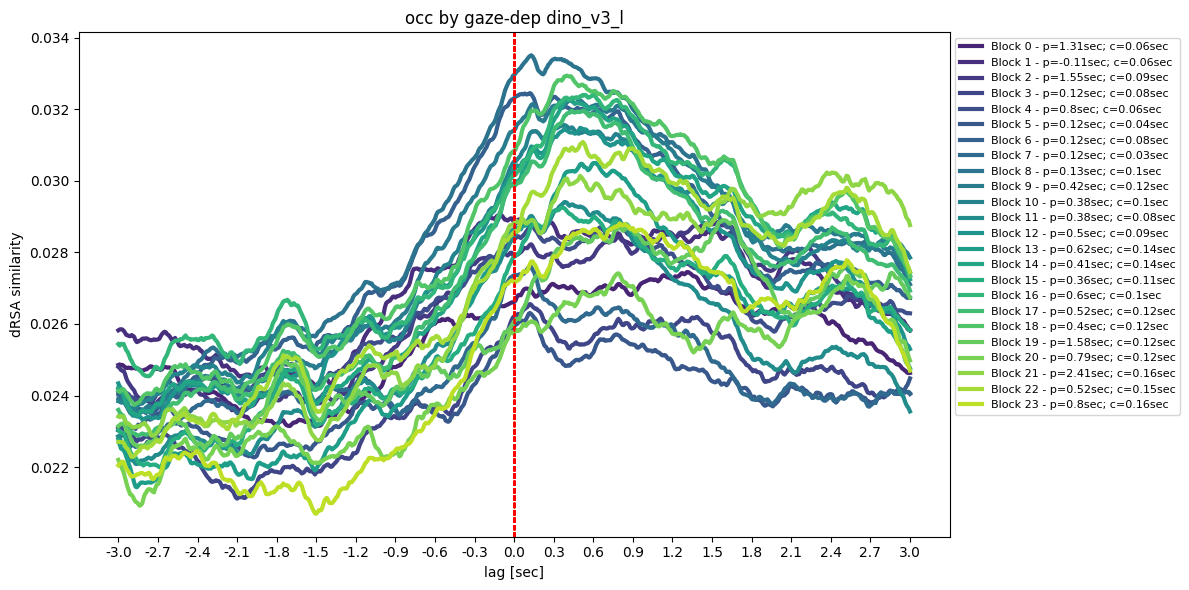

In [40]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.subsampling_lagged_comparisons import save_lagged_comparisons
tick_step = 30
lagplots = []
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, 24))
peaks = []
centroids = []
max_lag = 300
ticks = np.arange(-max_lag, max_lag + 1, tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += max_lag
plt.figure(figsize=(12, 6))
for idx, l in enumerate(layers):
    try:
        full_model_name = f"{cfg.model_name}_{l}"
        res_path = save_lagged_comparisons(paths, cfg.analysis_type+"A2B", cfg.sub_num, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
        res = loadmat(res_path)[cfg.analysis_type]
        lagplot = get_lagplot(1-res, max_lag)
        lagplots.append(lagplot)
        # --- compute peak ---
        peak_idx = np.argmax(lagplot)
        lags = np.arange(-max_lag, max_lag + 1)

        weights = lagplot.copy()
        weights[weights < 0] = 0  # optional but recommended

        centroid = np.sum(lags * weights) / np.sum(weights)
        centroid_lag = np.round(centroid / cfg.neu_fs, 2)
        peak_val = lagplot[peak_idx]
        peak_lag = (peak_idx - max_lag) / cfg.neu_fs  # convert to seconds
        peaks.append(peak_lag)
        centroids.append(centroid_lag)
        plt.plot(lagplot, linewidth=3, label=f"Block {idx} - p={peak_lag}sec; c={centroid_lag}sec", color=colors[idx])
        plt.ylabel("dRSA similarity")
        plt.xlabel("lag [sec]")
        plt.xticks(ticks, ticks_labels)
        plt.axvline(max_lag, color="r", linestyle="--", linewidth=1)
        

    except FileNotFoundError:
        print(f"{res_path} not found")
        pass
plt.title(f"{cfg.sensors_group} by gaze-dep {cfg.model_name}")#{cfg.sensors_group} sensors - regr out")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

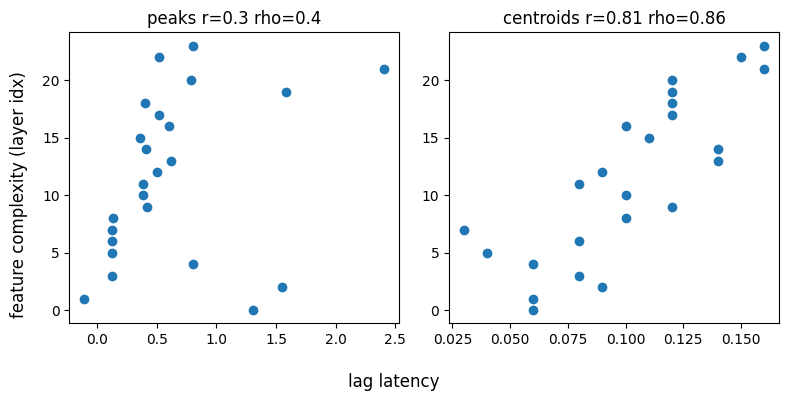

In [41]:
from useful_stuff.general_utils.utils import spearman
max_lag = 200
tick_step = 40
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].scatter(np.array(peaks), np.arange(len(peaks)))
rho = np.round(spearman(np.arange(len(peaks)), np.array(peaks)),2)
r = round(np.corrcoef(np.arange(len(peaks)), np.array(peaks))[0,1],2)
ax[0].set_title(f"peaks r={r} rho={rho}")
ax[1].scatter(centroids, np.arange(len(centroids)));
rho = np.round(spearman(np.arange(len(peaks)), np.array(centroids)), 2)
r = round(np.corrcoef(np.arange(len(centroids)), np.array(centroids))[0,1],2)
ax[1].set_title(f"centroids r={r} rho={rho}")
fig.supxlabel("lag latency")
fig.supylabel("feature complexity (layer idx)")
fig.tight_layout()

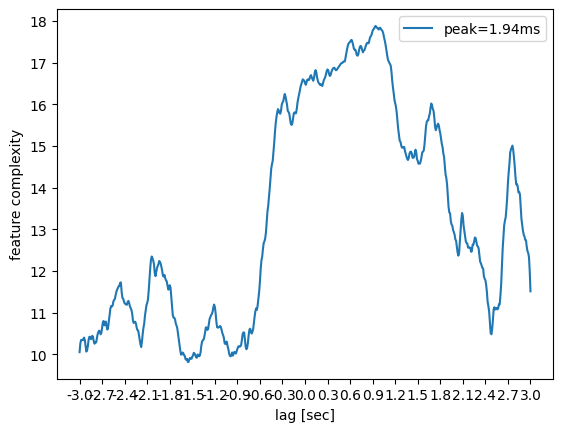

In [42]:
from useful_stuff.general_utils.utils import softmax

softmax_lp = []
hardmax = []
temp = .001
for t in range(lps.shape[1]):
    softmax_lp.append(softmax(lps[:,t], T=temp)@np.arange(lps.shape[0]))
    hardmax.append(np.argmax(lps[2:,t]))
plt.xticks(ticks, ticks_labels)
plt.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-max_lag)/cfg.neu_fs}ms")
# plt.plot(hardmax)
plt.xlabel("lag [sec]")
plt.ylabel("feature complexity")
plt.legend()

# B2A

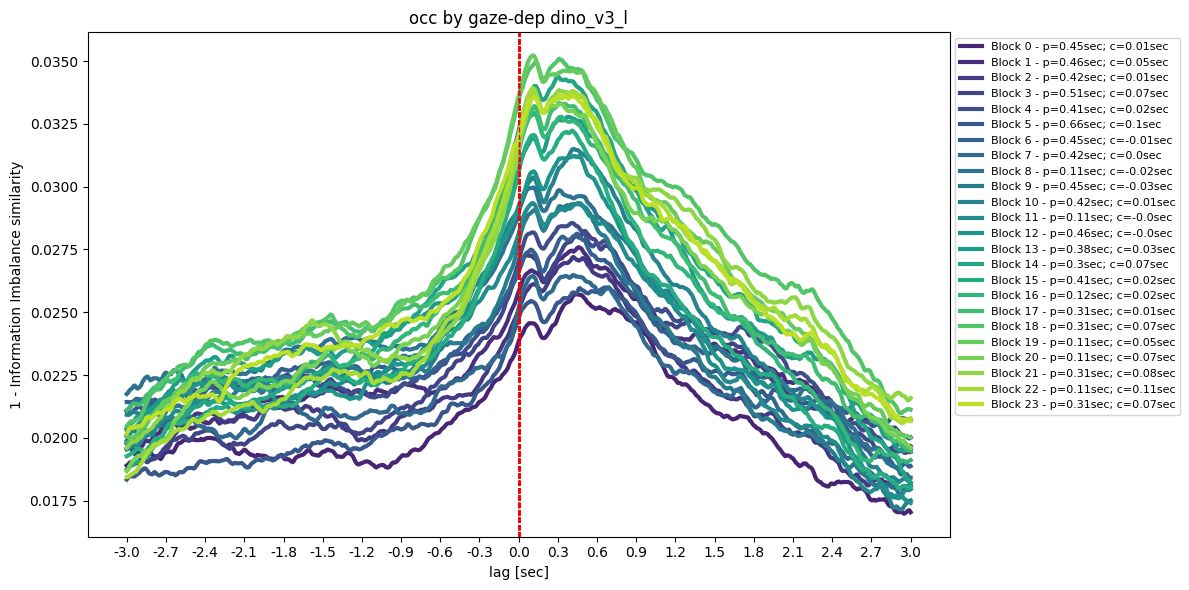

In [52]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.subsampling_lagged_comparisons import save_lagged_comparisons
tick_step = 30
lagplots = []
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, 24))
peaks = []
centroids = []
max_lag = 300
ticks = np.arange(-max_lag, max_lag + 1, tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += max_lag
plt.figure(figsize=(12, 6))
for idx, l in enumerate(layers):
    try:
        full_model_name = f"{cfg.model_name}_{l}"
        res_path = save_lagged_comparisons(paths, cfg.analysis_type+"B2A", cfg.sub_num, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
        res = loadmat(res_path)[cfg.analysis_type]
        lagplot = get_lagplot(1-res, max_lag)
        lagplots.append(lagplot)
        # --- compute peak ---
        peak_idx = np.argmax(lagplot)
        lags = np.arange(-max_lag, max_lag + 1)

        weights = lagplot.copy()
        weights[weights < 0] = 0  # optional but recommended

        centroid = np.sum(lags * weights) / np.sum(weights)
        centroid_lag = np.round(centroid / cfg.neu_fs, 2)
        peak_val = lagplot[peak_idx]
        peak_lag = (peak_idx - max_lag) / cfg.neu_fs  # convert to seconds
        peaks.append(peak_lag)
        centroids.append(centroid_lag)
        plt.plot(lagplot, linewidth=3, label=f"Block {idx} - p={peak_lag}sec; c={centroid_lag}sec", color=colors[idx])
        plt.ylabel("1 - Information Imbalance similarity")
        plt.xlabel("lag [sec]")
        plt.xticks(ticks, ticks_labels)
        plt.axvline(max_lag, color="r", linestyle="--", linewidth=1)
        

    except FileNotFoundError:
        print(f"{res_path} not found")
        pass
plt.title(f"{cfg.sensors_group} by gaze-dep {cfg.model_name}")#{cfg.sensors_group} sensors - regr out")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

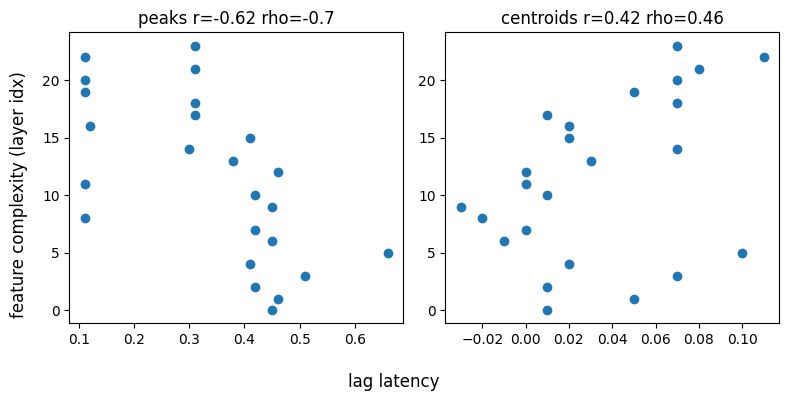

In [49]:
from useful_stuff.general_utils.utils import spearman
max_lag = 200
tick_step = 40
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].scatter(np.array(peaks), np.arange(len(peaks)))
rho = np.round(spearman(np.arange(len(peaks)), np.array(peaks)),2)
r = round(np.corrcoef(np.arange(len(peaks)), np.array(peaks))[0,1],2)
ax[0].set_title(f"peaks r={r} rho={rho}")
ax[1].scatter(centroids, np.arange(len(centroids)));
rho = np.round(spearman(np.arange(len(peaks)), np.array(centroids)), 2)
r = round(np.corrcoef(np.arange(len(centroids)), np.array(centroids))[0,1],2)
ax[1].set_title(f"centroids r={r} rho={rho}")
fig.supxlabel("lag latency")
fig.supylabel("feature complexity (layer idx)")
fig.tight_layout()

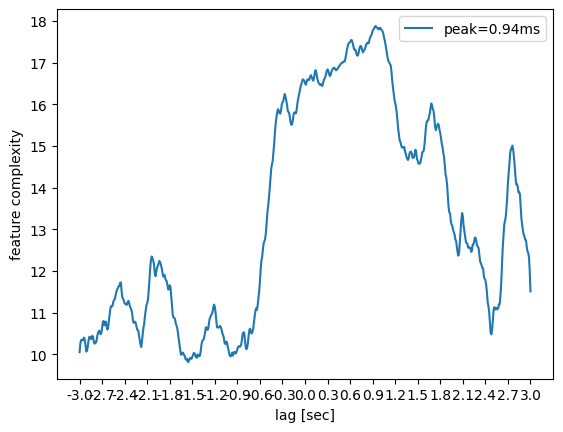

In [46]:
from useful_stuff.general_utils.utils import softmax
lps = np.stack(lagplots, axis=0)
softmax_lp = []
hardmax = []
temp = .001
for t in range(lps.shape[1]):
    softmax_lp.append(softmax(lps[:,t], T=temp)@np.arange(lps.shape[0]))
    hardmax.append(np.argmax(lps[2:,t]))
plt.xticks(ticks, ticks_labels)
plt.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-max_lag)/cfg.neu_fs}ms")
# plt.plot(hardmax)
plt.xlabel("lag [sec]")
plt.ylabel("feature complexity")
plt.legend()